<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG12f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

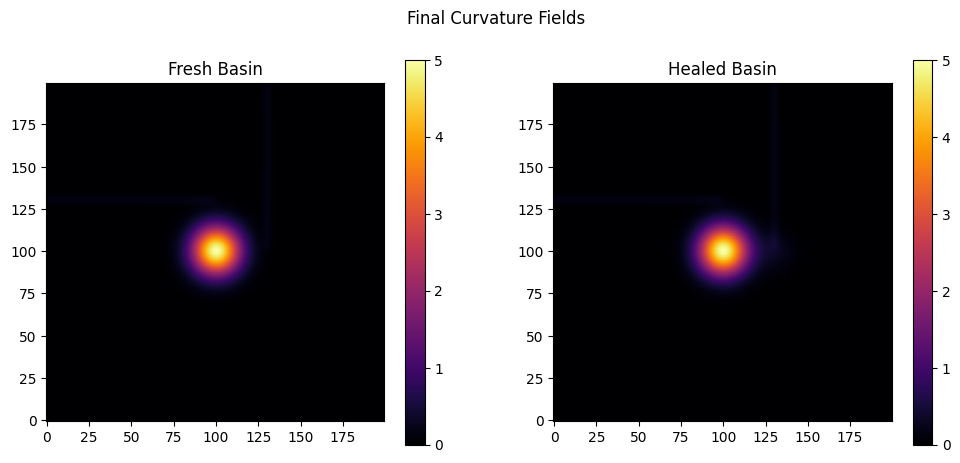

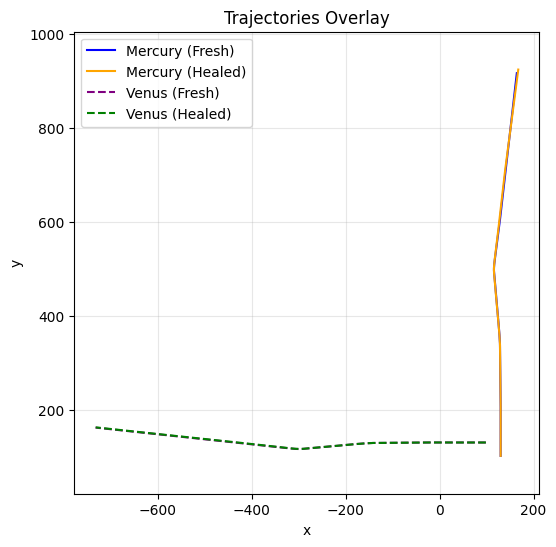

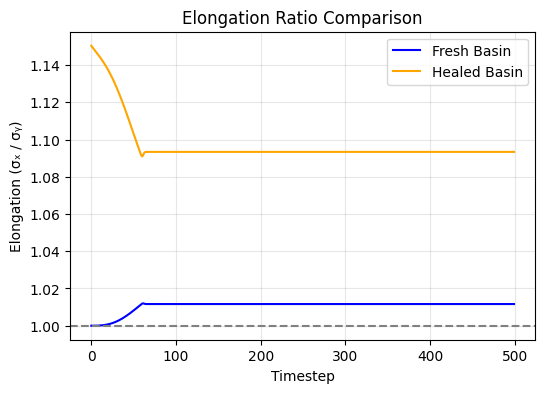

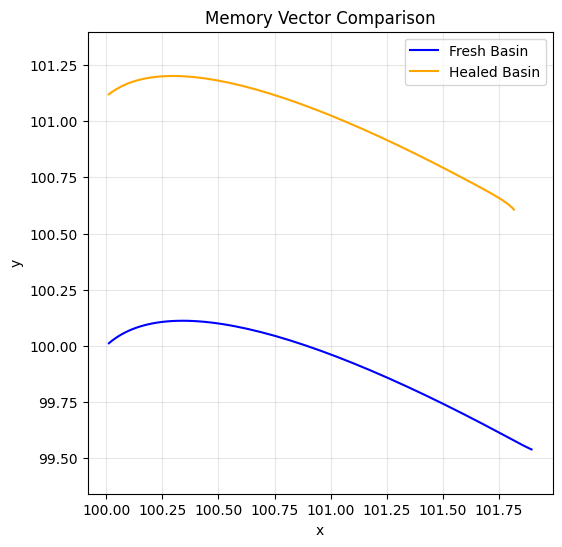

In [1]:
# TEG012F — Basin Reset Comparison
# Compare fresh basin vs healed basin to test memory permanence

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass

# === Parameters ===
grid_size = 200
timesteps = 500
A_sun = 5.0
sigma_sun = 10
A_body = 0.05
sigma_body = 2
sun_pos = (100, 100)

# === Coordinate Grid ===
X, Y = np.meshgrid(np.arange(grid_size), np.arange(grid_size))

# === Function: Initialize Basin ===
def init_basin():
    curvature = np.zeros((grid_size, grid_size))
    dx_sun = X - sun_pos[0]
    dy_sun = Y - sun_pos[1]
    curvature += A_sun * np.exp(-(dx_sun**2 + dy_sun**2) / (2 * sigma_sun**2))
    return curvature

# === Function: Run Simulation ===
def run_simulation(curvature_init):
    curvature = curvature_init.copy()
    mercury_pos = np.array([130.0, 100.0])
    mercury_vel = np.array([0.0, 1.5])
    venus_pos = np.array([100.0, 130.0])
    venus_vel = np.array([-1.5, 0.0])

    mercury_traj = []
    venus_traj = []
    elongation_history = []
    memory_vector = []

    def weighted_std(values, weights):
        avg = np.average(values, weights=weights)
        var = np.average((values - avg)**2, weights=weights)
        return np.sqrt(var)

    for t in range(timesteps):
        grad_y, grad_x = np.gradient(curvature)

        # Mercury
        fx_m = -grad_x[int(mercury_pos[1]) % grid_size, int(mercury_pos[0]) % grid_size]
        fy_m = -grad_y[int(mercury_pos[1]) % grid_size, int(mercury_pos[0]) % grid_size]
        mercury_vel += np.array([fx_m, fy_m]) * 0.1
        mercury_pos += mercury_vel
        mercury_traj.append(mercury_pos.copy())

        # Venus
        fx_v = -grad_x[int(venus_pos[1]) % grid_size, int(venus_pos[0]) % grid_size]
        fy_v = -grad_y[int(venus_pos[1]) % grid_size, int(venus_pos[0]) % grid_size]
        venus_vel += np.array([fx_v, fy_v]) * 0.1
        venus_pos += venus_vel
        venus_traj.append(venus_pos.copy())

        # Curvature bumps
        for pos in [mercury_pos, venus_pos]:
            dx = X - pos[0]
            dy = Y - pos[1]
            bump = A_body * np.exp(-(dx**2 + dy**2) / (2 * sigma_body**2))
            curvature += bump

        # Elongation
        x_proj = np.sum(curvature, axis=0)
        y_proj = np.sum(curvature, axis=1)
        elong_x = weighted_std(np.arange(grid_size), x_proj)
        elong_y = weighted_std(np.arange(grid_size), y_proj)
        elongation_history.append(elong_x / (elong_y + 1e-8))

        # Memory vector
        com = center_of_mass(curvature)
        memory_vector.append(com)

    return curvature, mercury_traj, venus_traj, elongation_history, memory_vector

# === Run Fresh Basin ===
curvature_fresh = init_basin()
results_fresh = run_simulation(curvature_fresh)

# === Run Healed Basin (simulated by adding prior trench deformation) ===
curvature_healed = init_basin()
dx = X - 130
dy = Y - 100
scar = 0.3 * np.exp(-(dx**2 + dy**2) / (2 * 8**2))
curvature_healed += scar
results_healed = run_simulation(curvature_healed)

# === Plot 1: Final Curvature Fields ===
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(results_fresh[0], cmap='inferno', origin='lower')
plt.title('Fresh Basin')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(results_healed[0], cmap='inferno', origin='lower')
plt.title('Healed Basin')
plt.colorbar()
plt.suptitle('Final Curvature Fields')
plt.show()

# === Plot 2: Trajectories Overlay ===
plt.figure(figsize=(6,6))
plt.plot(np.array(results_fresh[1])[:,0], np.array(results_fresh[1])[:,1], label='Mercury (Fresh)', color='blue')
plt.plot(np.array(results_healed[1])[:,0], np.array(results_healed[1])[:,1], label='Mercury (Healed)', color='orange')
plt.plot(np.array(results_fresh[2])[:,0], np.array(results_fresh[2])[:,1], label='Venus (Fresh)', color='purple', linestyle='--')
plt.plot(np.array(results_healed[2])[:,0], np.array(results_healed[2])[:,1], label='Venus (Healed)', color='green', linestyle='--')
plt.title('Trajectories Overlay')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

# === Plot 3: Elongation Ratio Comparison ===
plt.figure(figsize=(6,4))
plt.plot(results_fresh[3], label='Fresh Basin', color='blue')
plt.plot(results_healed[3], label='Healed Basin', color='orange')
plt.title('Elongation Ratio Comparison')
plt.xlabel('Timestep'); plt.ylabel('Elongation (σₓ / σᵧ)')
plt.legend(); plt.grid(alpha=0.3)
plt.axhline(1.0, color='gray', linestyle='--')
plt.show()

# === Plot 4: Memory Vector Comparison ===
mem_fresh = np.array(results_fresh[4])
mem_healed = np.array(results_healed[4])
plt.figure(figsize=(6,6))
plt.plot(mem_fresh[:,0], mem_fresh[:,1], label='Fresh Basin', color='blue')
plt.plot(mem_healed[:,0], mem_healed[:,1], label='Healed Basin', color='orange')
plt.title('Memory Vector Comparison')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()
